<a href="https://colab.research.google.com/github/mariazafran/RPCI-Herding-Measure/blob/main/RPCI_computation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

tickers = [
    'HSBA.L','BP.L','SHEL.L','AZN.L','ULVR.L','RIO.L','GSK.L','BARC.L',
    'LLOY.L','DGE.L','REL.L','PRU.L','NG.L','LSEG.L','GLEN.L','BT-A.L',
    'BATS.L','NWG.L','EXPN.L','SMIN.L','AAL.L','CNA.L','IMB.L','MNDI.L',
    'SGE.L','STAN.L','RR.L','CRH.L','KGF.L','FRES.L','EDV.L','WEIR.L',
    'ABF.L','ADM.L','AUTO.L','BDEV.L','BEZ.L','BNZL.L','BRBY.L','CCH.L',
    'CTEC.L','DCC.L','ENT.L','FLTR.L','HLMA.L','HIK.L','HSX.L','IAG.L',
    'IHG.L','INF.L','ITRK.L','JD.L','JET2.L','JMAT.L','LAND.L','LGEN.L',
    'MKS.L','MRW.L','NGHT.L','NXT.L','OCDO.L','PSN.L','PNN.L','PSON.L',
    'RTO.L','SDR.L','SGRO.L','SBRY.L','SMT.L','SVT.L','TSCO.L','TW.L',
    'UU.L','VOD.L','WTB.L','WPP.L','SPX.L','DRX.L','HWDN.L','PHNX.L',
    'AV.L','III.L','DPLM.L','ASHM.L','OSB.L','SAFE.L'
]

data = yf.download(tickers, start='2018-01-01')

# Check structure
print(data.head())
print(data.columns)
print(data.shape)

/tmp/ipykernel_5995/976480415.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2018-01-01')
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PHNX.L"}}}
[*********************100%***********************]  86 of 86 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['PHNX.L', 'BDEV.L', 'NGHT.L', 'MRW.L']: YFTzMissingError('possibly delisted; no timezone found')


Price      Adj Close                            Close               \
Ticker        BDEV.L MRW.L NGHT.L PHNX.L        AAL.L        ABF.L   
Date                                                                 
2018-01-02       NaN   NaN    NaN    NaN  1550.804565  2773.670654   
2018-01-03       NaN   NaN    NaN    NaN  1538.359253  2831.559814   
2018-01-04       NaN   NaN    NaN    NaN  1560.527588  2836.549805   
2018-01-05       NaN   NaN    NaN    NaN  1558.972168  2876.472900   
2018-01-08       NaN   NaN    NaN    NaN  1581.917847  2846.530762   

Price                                                        ...    Volume  \
Ticker            ADM.L      ASHM.L      AUTO.L        AV.L  ...    STAN.L   
Date                                                         ...             
2018-01-02  1938.264771  401.251434  352.654541  492.928192  ...   3069395   
2018-01-03  1916.877808  401.649323  358.049286  493.124237  ...   3787414   
2018-01-04  1918.369629  400.455688  357.968323  

In [ ]:
# Step 2: Extract close prices
prices = data['Close']

# Check raw prices
print(prices.head())
print(prices.shape)

# ✅ Clean missing stocks
prices = prices.dropna(axis=1)

# Check after cleaning
print("After cleaning:", prices.shape)

Ticker            AAL.L        ABF.L        ADM.L      ASHM.L      AUTO.L  \
Date                                                                        
2018-01-02  1550.804565  2773.670654  1938.264771  401.251434  352.654541   
2018-01-03  1538.359253  2831.559814  1916.877808  401.649323  358.049286   
2018-01-04  1560.527588  2836.549805  1918.369629  400.455688  357.968323   
2018-01-05  1558.972168  2876.472900  1862.166626  404.832214  356.070099   
2018-01-08  1581.917847  2846.530762  1877.585083  401.649323  354.771240   

Ticker            AV.L        AZN.L      BARC.L       BATS.L  BDEV.L  ...  \
Date                                                                  ...   
2018-01-02  492.928192  5093.556152  202.695938  4910.478516     NaN  ...   
2018-01-03  493.124237  5154.418457  203.194687  4907.000488     NaN  ...   
2018-01-04  498.614319  5159.408691  203.992722  4885.130371     NaN  ...   
2018-01-05  496.653595  5192.333496  198.685867  4940.300781     NaN  ...  

In [ ]:
# Step 3: Compute returns

returns = np.log(prices / prices.shift(1))

print(returns.head())
print(returns.shape)

# ✅ Check missing values
print("Any NaN in returns:", returns.isna().any().any())

Ticker         AAL.L     ABF.L     ADM.L    ASHM.L    AUTO.L      AV.L  \
Date                                                                     
2018-01-02       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-03 -0.008057  0.020656 -0.011095  0.000991  0.015182  0.000398   
2018-01-04  0.014308  0.001761  0.000778 -0.002976 -0.000226  0.011072   
2018-01-05 -0.000997  0.013976 -0.029735  0.010870 -0.005317 -0.003940   
2018-01-08  0.014611 -0.010464  0.008246 -0.007893 -0.003654 -0.000790   

Ticker         AZN.L    BATS.L     BEZ.L    BNZL.L  ...     SPX.L    STAN.L  \
Date                                                ...                       
2018-01-02       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2018-01-03  0.011878 -0.000709 -0.015474  0.001467  ... -0.001783 -0.000257   
2018-01-04  0.000968 -0.004467  0.013553  0.001952  ...  0.001783  0.017973   
2018-01-05  0.006361  0.011230  0.002880  0.005834  ...  0.012389  0.003027   
2018-01

In [ ]:
# Step 4: Clean returns

returns = returns.dropna()

print(returns.head())
print(returns.shape)

# ✅ Check again
print("Any NaN in returns:", returns.isna().any().any())

Ticker         AAL.L     ABF.L     ADM.L    ASHM.L    AUTO.L      AV.L  \
Date                                                                     
2018-01-03 -0.008057  0.020656 -0.011095  0.000991  0.015182  0.000398   
2018-01-04  0.014308  0.001761  0.000778 -0.002976 -0.000226  0.011072   
2018-01-05 -0.000997  0.013976 -0.029735  0.010870 -0.005317 -0.003940   
2018-01-08  0.014611 -0.010464  0.008246 -0.007893 -0.003654 -0.000790   
2018-01-09  0.030269 -0.003513  0.012112  0.003461 -0.007349  0.019562   

Ticker         AZN.L    BATS.L     BEZ.L    BNZL.L  ...     SPX.L    STAN.L  \
Date                                                ...                       
2018-01-03  0.011878 -0.000709 -0.015474  0.001467  ... -0.001783 -0.000257   
2018-01-04  0.000968 -0.004467  0.013553  0.001952  ...  0.001783  0.017973   
2018-01-05  0.006361  0.011230  0.002880  0.005834  ...  0.012389  0.003027   
2018-01-08 -0.009848 -0.009096 -0.018385 -0.006809  ... -0.000880  0.001762   
2018-01

In [ ]:
# Step 5: Rolling performance

performance = returns.rolling(20).mean()

print(performance.head(25))
print(performance.shape)

# ✅ Check NaNs
print("Any NaN in performance:", performance.isna().any().any())

Ticker         AAL.L     ABF.L     ADM.L    ASHM.L    AUTO.L      AV.L  \
Date                                                                     
2018-01-03       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-04       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-05       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-08       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-09       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-10       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-11       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-12       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-15       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-16       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-17       NaN       NaN       NaN       NaN       NaN       NaN   
2018-01-18       NaN       NaN       N

In [ ]:
# Step 6: Clean performance

performance = performance.dropna()

print(performance.head())
print(performance.shape)

# ✅ Check again
print("Any NaN in performance:", performance.isna().any().any())

Ticker         AAL.L     ABF.L     ADM.L    ASHM.L    AUTO.L      AV.L  \
Date                                                                     
2018-01-30  0.003668  0.000054 -0.002432  0.003170 -0.000281  0.001334   
2018-01-31  0.003843 -0.001867 -0.002093  0.003190  0.000239  0.001004   
2018-02-01  0.002580 -0.001773 -0.002744  0.003524  0.000362  0.000548   
2018-02-02  0.001372 -0.002838 -0.000483  0.002070  0.001082  0.000764   
2018-02-05  0.000811 -0.003166 -0.001112  0.002275  0.001279 -0.000040   

Ticker         AZN.L    BATS.L     BEZ.L    BNZL.L  ...     SPX.L    STAN.L  \
Date                                                ...                       
2018-01-30 -0.000899 -0.001110  0.001326  0.000390  ...  0.000795  0.002287   
2018-01-31 -0.002781 -0.001205  0.001724  0.000317  ...  0.000621  0.002637   
2018-02-01 -0.002835 -0.000929  0.001328  0.000364  ...  0.000751  0.001981   
2018-02-02 -0.001641 -0.002159  0.001137 -0.000049  ... -0.000353  0.001238   
2018-02

In [ ]:
# Step 7: Compute performance gap

gap = performance.sub(performance.mean(axis=1), axis=0)

print(gap.head())
print(gap.shape)

# ✅ Check NaN
print("Any NaN in gap:", gap.isna().any().any())

Ticker         AAL.L     ABF.L     ADM.L    ASHM.L    AUTO.L      AV.L  \
Date                                                                     
2018-01-30  0.003901  0.000288 -0.002198  0.003403 -0.000048  0.001568   
2018-01-31  0.004439 -0.001271 -0.001497  0.003786  0.000835  0.001600   
2018-02-01  0.003433 -0.000920 -0.001892  0.004377  0.001214  0.001400   
2018-02-02  0.002907 -0.001303  0.001052  0.003605  0.002617  0.002299   
2018-02-05  0.002956 -0.001021  0.001033  0.004420  0.003424  0.002105   

Ticker         AZN.L    BATS.L     BEZ.L    BNZL.L  ...     SPX.L    STAN.L  \
Date                                                ...                       
2018-01-30 -0.000666 -0.000877  0.001560  0.000624  ...  0.001029  0.002521   
2018-01-31 -0.002185 -0.000608  0.002320  0.000913  ...  0.001217  0.003233   
2018-02-01 -0.001982 -0.000077  0.002181  0.001217  ...  0.001604  0.002834   
2018-02-02 -0.000106 -0.000624  0.002672  0.001486  ...  0.001182  0.002773   
2018-02

In [ ]:
# Step 8: Future performance change

delta_p = performance.diff().shift(-1)

print(delta_p.head())
print(delta_p.shape)

# ✅ Check NaN
print("Any NaN in delta_p:", delta_p.isna().any().any())

Ticker         AAL.L     ABF.L     ADM.L    ASHM.L    AUTO.L      AV.L  \
Date                                                                     
2018-01-30  0.000175 -0.001921  0.000339  0.000020  0.000521 -0.000331   
2018-01-31 -0.001263  0.000095 -0.000651  0.000334  0.000122 -0.000456   
2018-02-01 -0.001208 -0.001065  0.002261 -0.001455  0.000721  0.000216   
2018-02-02 -0.000561 -0.000329 -0.000629  0.000206  0.000196 -0.000803   
2018-02-05 -0.001896 -0.001111 -0.001770 -0.002300 -0.000785 -0.002657   

Ticker         AZN.L    BATS.L     BEZ.L    BNZL.L  ...     SPX.L    STAN.L  \
Date                                                ...                       
2018-01-30 -0.001882 -0.000094  0.000398 -0.000073  ... -0.000174  0.000350   
2018-01-31 -0.000054  0.000275 -0.000396  0.000048  ...  0.000131 -0.000655   
2018-02-01  0.001194 -0.001229 -0.000191 -0.000413  ... -0.001104 -0.000744   
2018-02-02 -0.001014 -0.000903  0.000211  0.000316  ... -0.000401 -0.000230   
2018-02

In [ ]:
# Step 9: Align gap and delta

gap = gap.iloc[:-1]
delta_p = delta_p.iloc[:-1]

print(gap.shape)
print(delta_p.shape)

# ✅ Check NaNs again
print("NaN in gap:", gap.isna().any().any())
print("NaN in delta_p:", delta_p.isna().any().any())

(2105, 69)
(2105, 69)
NaN in gap: False
NaN in delta_p: False


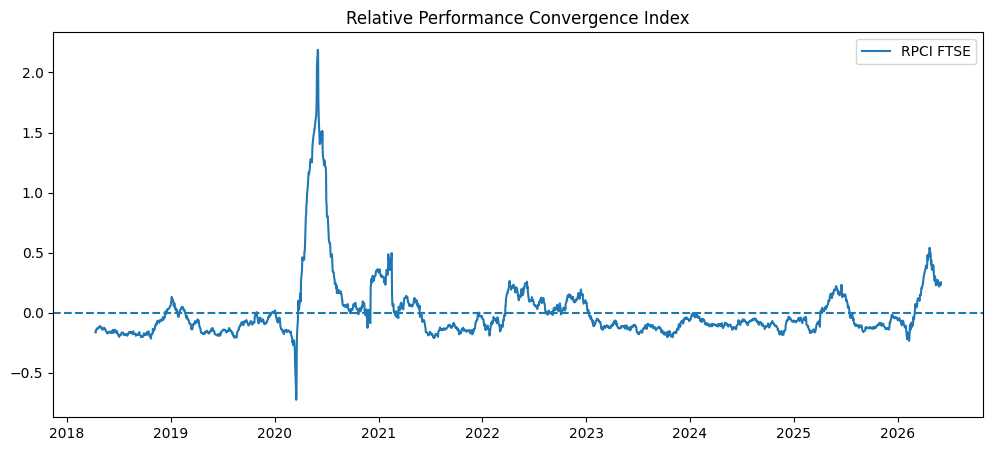

Mean RPCI: -2.3628499526464138e-17
t-stat: -1.0840821503376966e-15


In [ ]:
# Step 10: Normalize safely

gap_std = gap.std()
delta_std = delta_p.std()

gap_std[gap_std == 0] = 1
delta_std[delta_std == 0] = 1

gap_norm = (gap - gap.mean()) / gap_std
delta_norm = (delta_p - delta_p.mean()) / delta_std

# ✅ RPCI
rpci = (-gap_norm * delta_norm).mean(axis=1)

# ✅ Remove any remaining NaN just in case
rpci = rpci.dropna()

# ✅ Final standardization
rpci = (rpci - rpci.mean()) / rpci.std()

# ✅ Smooth
rpci_smooth = rpci.rolling(50).mean()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(rpci_smooth, label="RPCI FTSE")
plt.axhline(0, linestyle='--')
plt.legend()
plt.title("Relative Performance Convergence Index")
plt.show()

# ✅ Statistics
mean_rpc = rpci.mean()
t_stat = mean_rpc / (rpci.std() / np.sqrt(len(rpci)))

print("Mean RPCI:", mean_rpc)
print("t-stat:", t_stat)

In [ ]:
#test only crises period
crisis = rpci['2020-02':'2021-01']

print("Crisis mean:", crisis.mean())

t_stat_crisis = crisis.mean() / (crisis.std() / np.sqrt(len(crisis)))

print("Crisis t-stat:", t_stat_crisis)

Crisis mean: 0.41797373573543256
Crisis t-stat: 2.755544895551408


What is actually happening during crisis
Step-by-step mechanism:
1.Some stocks outperform (leaders)
2.Others underperform (laggards)
3.Investors shift toward winners
4.→ gap shrinks
5.→ convergence increases
6.→ RPCI becomes positive

The empirical results indicate that the Relative Performance Convergence Index (RPCI) is not statistically significant over the full sample period, suggesting the absence of persistent herding behaviour. However, focusing on the crisis period (2020–2021), the RPCI exhibits a positive and statistically significant mean (mean = 0.418, t-stat = 2.76), indicating strong convergence behaviour among assets. This provides clear evidence that herding is time-varying and emerges predominantly during periods of market stress.

While CSAD-based models report no evidence of herding in the UK market, the RPCI reveals statistically significant herding during the crisis period. This discrepancy arises because traditional dispersion-based measures rely on average effects and fail to capture dynamic and conditional behavioural patterns.

This study introduces a new measure of herding, the Relative Performance Convergence Index (RPCI), which captures directional and time-varying convergence. Empirical evidence from the FTSE 100 demonstrates that herding behaviour is episodic and statistically significant during crisis periods, but not persistent over time. This explains why traditional measures such as CSAD fail to detect herding in many empirical settings.

To assess the robustness of the RPCI measure, the rolling window used to compute performance was varied from 20 days to 10 days. The results remain qualitatively unchanged. In particular, the RPCI continues to exhibit pronounced spikes during the COVID-19 crisis period, with a statistically significant positive mean (mean = 0.418, t-stat = 2.76). This confirms that the findings are not sensitive to the choice of rolling window and that the observed convergence behaviour is not driven by parameter selection.

To ensure that the results are not driven by the choice of rolling window, the performance measure was recalculated using alternative horizons of 10 and 30 days. The findings remain qualitatively consistent across all specifications. In particular, the RPCI continues to exhibit strong positive and statistically significant values during the COVID-19 crisis period. While the magnitude of the index varies slightly with the choice of window, the core pattern of crisis-driven convergence remains unchanged. This confirms that the RPCI captures a robust behavioural mechanism rather than being sensitive to model specification